In [1]:
import numpy as np
from scipy import optimize
from scipy.constants import mu_0, epsilon_0
from scipy import fftpack
from scipy import sparse
from scipy.special import factorial
from scipy.signal import butter, filtfilt
from scipy.interpolate import interp1d, CubicSpline,splrep, BSpline
from scipy.sparse import csr_matrix, csc_matrix
import csv
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation
from IPython.display import display, Math, Latex, Markdown
from scipy.linalg import lu_factor, lu_solve
from scipy import signal
import ipywidgets as widgets
import empymod
import discretize
import  os
import glob
import json
import pandas as pd



In [2]:
from masa_utils import sci_latex
from masa_utils import InducedPolarizationSimulation
from masa_utils import Pelton_res_f, DDR_f, DDC_f
from masa_utils import Optimization 

In [3]:
plt.style.use('00_video.mplstyle')


In [4]:
# --- helper to render LaTeX labels (robust method) ---
def math_label(tex, width="160px"):
    out = widgets.Output(layout=widgets.Layout(width=width))
    with out:
        display(Math(tex))
    return out
def sci_latex(v, prec=2):
    s = f"{v:.{prec}e}"          # e.g. '3.00e-03'
    mant, exp = s.split('e')
    exp = int(exp)

    if float(mant) == 0:
        return "0"

    if exp in [0, -1]:
        return f"{float(mant)*10**exp:.{prec}f}"
    else:
        return rf"{mant}\cdot 10^{{{exp}}}"


def fmt(v, prec=2, latex=False, wrap=False):
    # blank for None or empty string
    if v is None or v == "":
        return ""

    # if already string → return as-is
    if isinstance(v, str):
        return v

    try:
        s = sci_latex(v, prec=prec)

        if latex:
            if wrap:
                return rf"$${s}$$"   # display math
            else:
                return rf"${s}$"     # inline math
        else:
            return s

    except:
        return ""


Prepare SIP to fit using Pelton model

In [5]:
# -----------------------------
# 2) Define your base values and sweep ranges
# -----------------------------
# Use your defaults here:
rho0_base = 0.3
eta_base  = 0.4
tau_base  = 1e-1
c_base    = 0.5

# Choose sweep ranges (edit these!)
tau_vals  = np.logspace(start=-3, stop=-1,base=10, num=121)
# c_vals    = np.linspace(start=0.3, stop=0.8, num = 101)

m_trues_1 = []
m_trues_2 = []
nmodel_cmb=[]

# sweep tau_rho
for t in tau_vals:
    m_trues_1.append(np.r_[np.log(rho0_base), eta_base, np.log(t), c_base])
for t in tau_vals[::-1]:  # reverse the list to go back to the start
    m_trues_1.append(np.r_[np.log(rho0_base), eta_base, np.log(t), c_base])

nmodel_cmb.append(len(m_trues_1))
# sweep c
for t in tau_vals:
    m_trues_2.append(np.r_[np.log(rho0_base), eta_base, np.log(t), c_base])
for t in tau_vals[::-1]:  # reverse the list to go back to the start
    m_trues_2.append(np.r_[np.log(rho0_base), eta_base, np.log(t), c_base])

nmodel_cmb.append(len(m_trues_2))
m_trues_cmb = []
m_trues_cmb.append(m_trues_1)
m_trues_cmb.append(m_trues_2)
print(nmodel_cmb)


[242, 242]


Prepare Widget

In [6]:
# Set Pelton for generating synthetic data
sim_obs_cmb=[]
sim_inv_cmb=[]
m_refs=[]

freq_start_log = -1
freq_end_log = 4
freq_step_log = 0.1
# Set Debye Decomposition model for inverting data
taus_step_log = 0.5

nfreq= int((freq_end_log - freq_start_log) / freq_step_log) + 1
freq_ext = np.logspace(freq_start_log, freq_end_log, nfreq)
IP_model = Pelton_res_f(freq=freq_ext)
sim_obs = InducedPolarizationSimulation(ip_model=IP_model, mode="sip")
sim_obs_cmb.append(sim_obs)
sim_obs_ext = InducedPolarizationSimulation(ip_model=IP_model, mode="sip")

ntau = int(round((freq_end_log - freq_start_log) / taus_step_log)) + 1
taus = np.logspace(-freq_end_log, -freq_start_log, ntau, base=10.0) / (2.0*np.pi)
IP_model =DDR_f(freq=freq_ext, taus=taus)
sim_inv = InducedPolarizationSimulation(ip_model=IP_model, mode="sip")
sim_inv_cmb.append(sim_inv)
m_ref = np.r_[np.log(rho0_base), np.zeros(ntau)]
m_refs.append(m_ref) 

taus_xlim_min, taus_xlim_max = taus.min()*0.9, taus.max()*1.1
freq_xlim_min, freq_xlim_max = freq_ext.min()*0.9, freq_ext.max()*1.1

freq_start_log = 2
freq_end_log = 4
freq_step_log = 0.1
nfreq= int((freq_end_log - freq_start_log) / freq_step_log) + 1
freq = np.logspace(freq_start_log, freq_end_log, nfreq)
IP_model = Pelton_res_f(freq=freq, chglim=0)
sim_obs = InducedPolarizationSimulation(ip_model=IP_model, mode="sip")
sim_obs_cmb.append(sim_obs)

ntau = int(round((freq_end_log - freq_start_log) / taus_step_log)) + 1
taus = np.logspace(-freq_end_log, -freq_start_log, ntau, base=10.0) / (2.0*np.pi)
IP_model =DDR_f(freq=freq, taus=taus)
sim_inv = InducedPolarizationSimulation(ip_model=IP_model, mode="sip")
IP_model =DDR_f(freq=freq_ext, taus=taus)
sim_inv_ext = InducedPolarizationSimulation(ip_model=IP_model, mode="sip")

sim_inv_cmb.append(sim_inv)
m_ref = np.r_[np.log(rho0_base), np.zeros(ntau)]
m_refs.append(m_ref) 



[<Axes: xlabel='Frequency (Hz)', ylabel='Amplitude ($\\Omega$m)'>,
 <Axes: xlabel='Frequency (Hz)', ylabel='Phase (deg)'>]

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


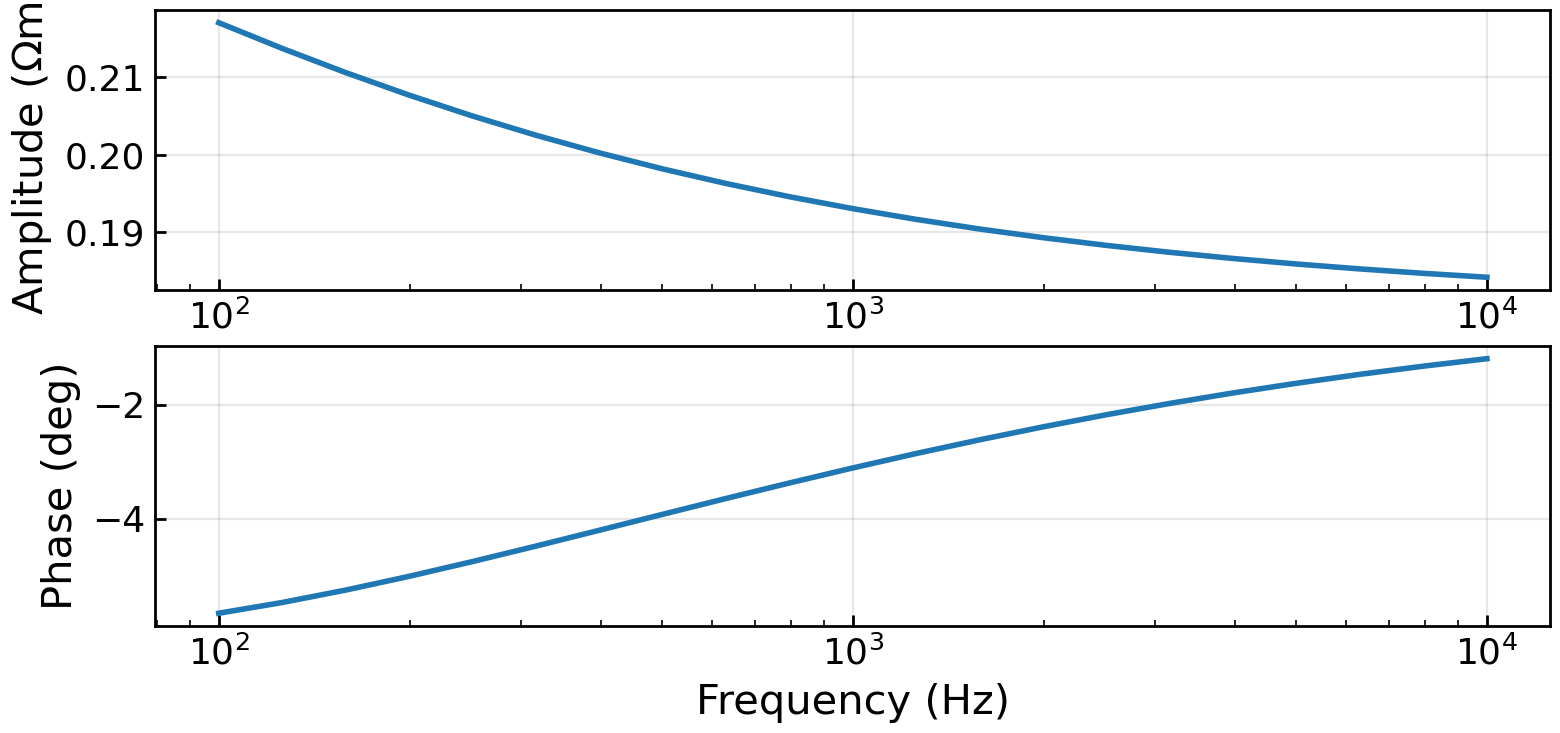

In [7]:
fig, ax= plt.subplots(2,1, figsize=(9,4), dpi=200)

ax= ax.flatten()
sim_obs.plot_sip_model(m_trues_1[50],ax=ax)

In [8]:
nmodel_cmb

[242, 242]

In [9]:
relative_error = 0.02
noise_floor_ratio = 1e-3
niter = 100
stol=1e-6
coolingFactor = 2.0
coolingRate = 2
mu=1e-3
beta0_ratio = 1
alphas= 1.0
Ws_threshold=1e-3

In [10]:
dobs_cmb=[]
dobs_cmb_abs_max = []
dobs_cmb_abs_min= []
noise_floor_cmb=[]
mpreds_cmb = []
dpreds_cmb = []
model_prgs_cmb = []
data_prgs_cmb = []
error_prgs_cmb = []
for j in range(2):
    sim_obs= sim_obs_cmb[j]
    m_trues = m_trues_cmb[j]
    sim_inv = sim_inv_cmb[j]
    m_ref = m_refs[j]
    dobs_cmb_j = []
    dobs_cmb_abs_max_j = []
    dobs_cmb_abs_min_j = []
    noise_floor_cmb_j = []
    mpreds_cmb_j = []
    dpreds_cmb_j = []
    model_prgs_cmb_j = []
    data_prgs_cmb_j = []
    error_prgs_cmb_j = []
    for i in range(nmodel_cmb[j]):
        m_true = m_trues[i]
        dobs = sim_obs.dpred(m_true)
        f_abs = abs(sim_obs.ip_model.f(m_true))
        dobs_cmb_j.append(dobs)
        dobs_cmb_abs_max_j.append(np.max(f_abs))
        dobs_cmb_abs_min_j.append(np.min(f_abs))
        noise_floor =noise_floor_ratio * np.max(f_abs)
        noise_floor_cmb_j.append(noise_floor)
        opt = Optimization(sim=sim_inv, dobs=dobs, alphas=alphas, Ws_threshold=Ws_threshold)
        opt.get_Wd(ratio=relative_error, plateau=noise_floor)
        opt.get_Ws(smallness=np.ones(len(m_ref)))
        beta0 = opt.BetaEstimate_byEig(
        mvec=m_ref, update_Wsen=True, beta0_ratio=beta0_ratio)
        print(beta0)
        mpred = opt.GaussNewton(
        mvec_init=m_ref,niter=niter,beta0=beta0, update_Wsen=True,
        stol=stol,mu=mu,coolingRate=coolingRate, coolingFactor=coolingFactor
        )

        mpreds_cmb_j.append(mpred)
        dpreds_cmb_j.append(opt.dpred(mpred))
        error_prgs_cmb_j.append(opt.error_prg)
        model_prgs_cmb_j.append(opt.mvec_prg)
        data_prgs_cmb_j.append(opt.data_prg)

    noise_floor_cmb.append(noise_floor_cmb_j)
    dobs_cmb.append(dobs_cmb_j)
    dobs_cmb_abs_max.append(dobs_cmb_abs_max_j)
    dobs_cmb_abs_min.append(dobs_cmb_abs_min_j)
    mpreds_cmb.append(mpreds_cmb_j) 
    dpreds_cmb.append(dpreds_cmb_j)
    error_prgs_cmb.append(error_prgs_cmb_j)
    model_prgs_cmb.append(model_prgs_cmb_j)
    data_prgs_cmb.append(data_prgs_cmb_j)

68454733.9937052
  1, beta:6.8e+07, step:1.0e+00, g:5.2e+05, phid:5.1e+04, phim:4.7e-05, f:5.5e+04 
  2, beta:6.8e+07, step:6.2e-02, g:5.5e+03, phid:5.1e+04, phim:4.7e-05, f:5.5e+04 
  3, beta:3.4e+07, step:1.0e+00, g:2.3e+05, phid:4.2e+04, phim:1.5e-04, f:4.7e+04 
  4, beta:3.4e+07, step:6.2e-02, g:4.0e+03, phid:4.2e+04, phim:1.5e-04, f:4.7e+04 
  5, beta:1.7e+07, step:1.0e+00, g:2.1e+05, phid:2.9e+04, phim:4.1e-04, f:3.6e+04 
  6, beta:1.7e+07, step:6.2e-02, g:5.3e+03, phid:2.9e+04, phim:4.1e-04, f:3.6e+04 
  7, beta:8.6e+06, step:1.0e+00, g:1.7e+05, phid:1.7e+04, phim:9.4e-04, f:2.5e+04 
  8, beta:8.6e+06, step:1.0e+00, g:5.3e+03, phid:1.7e+04, phim:9.3e-04, f:2.5e+04 
  9, beta:4.3e+06, step:1.0e+00, g:1.3e+05, phid:7.7e+03, phim:1.7e-03, f:1.5e+04 
 10, beta:4.3e+06, step:1.0e+00, g:3.7e+03, phid:7.7e+03, phim:1.7e-03, f:1.5e+04 
 11, beta:2.1e+06, step:1.0e+00, g:8.7e+04, phid:2.8e+03, phim:2.5e-03, f:8.1e+03 
 12, beta:2.1e+06, step:1.0e+00, g:1.8e+03, phid:2.8e+03, phim:2.5e-03

In [11]:
phid_star_ratio = 0.5
models_rec_phid_cmb = []

for j in range(2):
    model_prgs_j = model_prgs_cmb[j]
    dpreds_cmb_j = dpreds_cmb[j]
    data_prgs_cmb_j = data_prgs_cmb[j]
    error_prgs_cmb_j = error_prgs_cmb[j]
    models_rec_phid_cmb_j = []
    for i in range(nmodel_cmb[j]):
        phid_star = nfreq*2
        model_prg= np.array(model_prgs_j[i])
        data_prg = np.array(dpreds_cmb_j[i])
        error_prg = error_prgs_cmb_j[i]
        phid_prg = np.array(error_prg)[:,1]
        ind = phid_prg < phid_star*phid_star_ratio
        if np.sum(ind) == 0:
            ind = phid_prg == np.min(phid_prg)
            print(f" range {i}:No phid star found, take min phid")
        model = model_prg[ind][0]
        models_rec_phid_cmb_j.append(model)
        rho0_sip = np.exp(model[0])
        eta_sip = model[1:].sum()
        print(f"Model {i}: rho0: {rho0_sip:.2e}, eta: {eta_sip:.3f}")
    models_rec_phid_cmb.append(models_rec_phid_cmb_j)


Model 0: rho0: 3.00e-01, eta: 0.374
Model 1: rho0: 3.00e-01, eta: 0.374
Model 2: rho0: 3.00e-01, eta: 0.374
Model 3: rho0: 3.00e-01, eta: 0.375
Model 4: rho0: 3.00e-01, eta: 0.375
Model 5: rho0: 3.00e-01, eta: 0.375
Model 6: rho0: 3.00e-01, eta: 0.376
Model 7: rho0: 3.00e-01, eta: 0.376
Model 8: rho0: 3.00e-01, eta: 0.376
Model 9: rho0: 3.00e-01, eta: 0.377
Model 10: rho0: 3.00e-01, eta: 0.377
Model 11: rho0: 3.00e-01, eta: 0.377
Model 12: rho0: 3.00e-01, eta: 0.377
Model 13: rho0: 3.00e-01, eta: 0.378
Model 14: rho0: 2.99e-01, eta: 0.378
Model 15: rho0: 2.99e-01, eta: 0.378
Model 16: rho0: 2.99e-01, eta: 0.378
Model 17: rho0: 2.99e-01, eta: 0.379
Model 18: rho0: 2.99e-01, eta: 0.379
Model 19: rho0: 2.99e-01, eta: 0.379
Model 20: rho0: 2.99e-01, eta: 0.379
Model 21: rho0: 2.99e-01, eta: 0.380
Model 22: rho0: 2.99e-01, eta: 0.380
Model 23: rho0: 2.99e-01, eta: 0.380
Model 24: rho0: 2.99e-01, eta: 0.380
Model 25: rho0: 2.99e-01, eta: 0.380
Model 26: rho0: 2.99e-01, eta: 0.381
Model 27: r

# Plot time

In [12]:
# log10rho0min, log10rho0max = -1, 0
# rho0min, rho0max = 10**log10rho0min, 10**log10rho0max
# etamin, etamax = 0, 0.5
# log10taumin, log10taumax = -4, 1
# taumin, taumax = 10**log10taumin, 10**log10taumax
# cmin, cmax = 0.2., 1.0
# rho0_default, eta_default, tau_default, c_default = 0.3, 0.0,  1e-3, 0.5


In [13]:

print("usetex =", mpl.rcParams["text.usetex"])

usetex = False


In [14]:
# def draw_slider_vertical(ax, label, val, vmin, vmax, x, logscale=False, fmt_tau=False):
#     # normalize value → [0,1]
#     if logscale:
#         t = (np.log10(val) - np.log10(vmin)) / (np.log10(vmax) - np.log10(vmin))
#     else:
#         t = (val - vmin) / (vmax - vmin)

#     # background line
#     ax.plot([0.2, 0.8], [y, y], color='0.7', lw=6, solid_capstyle='round')

#     # knob
#     y = 0.2 + 0.6 * t
#     ax.plot(x, y, 'o', color='white', markeredgecolor='black', markersize=10)

#     # label
#     ax.text(x, 0.05, label, va='center', fontsize=14)

#     # current value
#     if fmt_tau:
#         ax.text(x, 0.90, f"${fmt(val, prec=1)}$", va='center', fontsize=14)
#     else:
#         ax.text(x, 0.90, f"{val:.2f}", va='center', fontsize=14)

#     # ---- NEW: min/max labels ----
#     if fmt_tau:
#         vmin_str = f"${fmt(vmin, prec=1)}$"
#         vmax_str = f"${fmt(vmax, prec=1)}$"
#     else:
#         vmin_str = f"{vmin:.2f}"
#         vmax_str = f"{vmax:.2f}"

#     ax.text(0.2, y-0.08, vmin_str, ha='center', va='top', color='0.3')
#     ax.text(0.8, y-0.08, vmax_str, ha='center', va='top', color='0.3')

In [15]:
#  Widget for the main function
def plot_DD_widget(
         j,i, widget=True,
         eta_hline_threshold=0.10, axsip=None,axetas=None):

    # Create the plot
    if widget:
        fig, ax = plt.subplots(3, 1, gridspec_kw={"height_ratios":[1.8,1,1]})
        fig.subplots_adjust(right=0.75)
        axsip = [ax[0], ax[1]]
        axetas = ax[2]
    else:
        assert axsip is not None
        assert axetas is not None
        axsip[0].clear()
        axsip[1].clear()
        axetas.clear()
    sim_obs = sim_obs_cmb[j]
    sim_inv = sim_inv_cmb[j]
    m_true = m_trues_cmb[j][i]
    mpred = models_rec_phid_cmb[j][i]
    if j == 1:
        axsip = sim_inv_ext.plot_sip_model(mpred, ax=axsip, color='C0', linestyle="-.", alpha=0.7 )
    axsip = sim_inv.plot_sip_model(mpred, ax=axsip, color='C0')
    axetas = sim_inv.ip_model.plot_etas(mpred,
            ax=axetas, color="C0",
            label="Est",
            linestyle="-", marker='o', markersize=4.0
            )

    if j == 1:
         axsip = sim_obs_ext.plot_sip_model(m_true, ax=axsip, color='C3', linestyle=':', alpha=0.7)
    axsip = sim_obs.plot_sip_model(m_true, ax=axsip, linestyle=':', color='C3')
    
    abs_max= dobs_cmb_abs_max[j][i]
    abs_min = dobs_cmb_abs_min[j][i]
    rho0_DD = np.exp(mpred[0])
    rho0_pel = np.exp(m_true[0])
    eta_DD = mpred[1:].sum()
    eta_pel =m_true[1]
    tau_pel = np.exp(m_true[2])
    cc_pel = m_true[3]

    label = f'DD $\\rho_0: {rho0_DD:.2f}$'
    axsip[0].axhline(y=rho0_DD, color='C0', linestyle='--', label=label)
    label = f'$|max(\\rho)|: {abs_max:.2f} $'
    axsip[0].axhline(y=abs_max, color='C2', linestyle='-.', label=label)
    label = f'PEL: $\\rho_0 = {rho0_pel:.2f}$'
    axsip[0].axhline(y=rho0_pel, color='C3', linestyle=':', label=label)

    label = f'DD $\\rho_0(1-\\sum\\eta_k): {rho0_DD*(1-eta_DD):.2f} $'
    axsip[0].axhline(y=rho0_DD*(1-eta_DD), color='C0', linestyle='--',
                        label=label)
    label = f'$|min(\\rho)|: {abs_min:.2f} $'
    axsip[0].axhline(y=abs_min, color='C2', linestyle='-.', label=label)
    label = f'PEL: $\\rho_0(1-\\eta): {rho0_pel*(1-eta_pel):.2f} $'
    axsip[0].axhline(y=rho0_pel*(1-eta_pel), color='C3', linestyle=':', label=label)

    for a in axsip:
        a.set_xlim(left=freq_xlim_max, right=freq_xlim_min)
        a.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
    axetas.set_xlim(left=taus_xlim_min, right=taus_xlim_max)

    axsip[1].set_ylim([0, -8])
    m_true_text = r"m_true\n" + r"$\rho_0$" + f": {rho0_pel: .2f} \n " + r"$\eta$" +f": {eta_pel: .2f} \n"  
    m_true_text += r"$\tau_\rho$"+ f": ${fmt(tau_pel, prec=1)}$ \n" +r"$C$" + f": {cc_pel: .2f}"

    # axsip[1].text(
    #     1.02, 1.0,
    #     m_true_text,
    #     transform=axsip[1].transAxes,
    #     va="top",
    #     ha="left",
    #     bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    # )

    # m_pred_text = r"m_pred\n" + r"$\rho_0$" + f": {rho0_DD: .2f} \n " + r"$\eta$" +f": {eta_DD: .2f} \n"
    # axetas.text(
    #     1.02, 1.0,
    #     m_pred_text,
    #     transform=axetas.transAxes,
    #     va="top",
    #     ha="left",
    #     bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    # )
    axetas.set_ylim([0, .2])
    axsip[0].set_xlabel("")
    if widget:
        return fig, axsip, axetas

In [16]:

# # --- sliders ---
# rho0_slider = widgets.FloatLogSlider(
#     base=10, min=log10rho0min, max=log10rho0max, step=0.01, value=rho0_default, description=""
# )

# eta_slider = widgets.FloatSlider(
#     min=etamin, max=etamax, step=0.01, value=eta_default, description=""
# )

# tau_slider = widgets.FloatLogSlider(
#     base=10, min=log10taumin, max=log10taumax, step=0.01, value=tau_default, description=""
# )

# c_slider = widgets.FloatSlider(
#     min=cmin, max=cmax, step=0.01, value=c_default, description=""
# )




In [17]:
i_slider = widgets.IntSlider(
    min=0, max=nmodel_cmb[0]-1, step=1, value=0,
    description=""
)
j_slider = widgets.IntSlider(
    min=0, max=1, step=1, value=0,
    description=""
)

i_row = widgets.HBox([
    widgets.Label("Model index", layout=widgets.Layout(width="180px")),
    i_slider
])

j_row = widgets.HBox([
    widgets.Label("F-band index", layout=widgets.Layout(width="180px")),
    j_slider
])

In [48]:
# # --- labeled rows ---
# rho0_row = widgets.HBox([
#     math_label(r"\rho_0\,(\Omega\,\mathrm{m})"),
#     rho0_slider
# ])

# eta_row = widgets.HBox([
#     math_label(r"\eta"),
#     eta_slider
# ])

# tau_row = widgets.HBox([
#     math_label(r"\tau_{\rho}\,(\mathrm{s})"),
#     tau_slider
# ])

# c_row = widgets.HBox([
#     math_label(r"c"),
#     c_slider
# ])


In [ ]:
# --- controls layout ---
controls = widgets.VBox([i_row, j_row])
# --- connect UI to function (NO duplicate sliders) ---
out = widgets.interactive_output(
    plot_DD_widget,
    {
        "i": i_slider,
        "j": j_slider,
    },
)

# --- display everything ---
display(controls, out)

In [ ]:
# -----------------------------
# video writer (no PNGs)
# -----------------------------
fps = 60
dpi = 150
writer = animation.FFMpegWriter(fps=fps, metadata={"artist": "matplotlib"})
out_mp4= [
    "../figures/38_DD_animation_band1.mp4",
    "../figures/38_DD_animation_band2.mp4"
]
for j in range(2):
    i=0
    fig, axsip, axetas = plot_DD_widget(j,i, widget=True)

    with writer.saving(fig, out_mp4, dpi=dpi):
        for i in range(1, nmodel_cmb[j]):
            # draw_pelton_on_axes(axsip, axui, rho0, eta, tau, c)
            plot_DD_widget(i=i,j=j,widget=False, axsip=axsip, axui=axetas)
            fig.subplots_adjust(right=0.78)
            fig.canvas.draw()     # ensure the canvas is updated
            writer.grab_frame()   # grab this frame from *this same fig*

    plt.close(fig)
    print(f"Saved animation: {out_mp4}")

Saved animation: ../figures/37_Pelton_challenge_animation.mp4
